# Practice — Pandas + NumPy (Iris)

Эталонные решения 10 упражнений по практике на датасете Iris.


## О датасете

Используем **Iris** из `sklearn.datasets.load_iris()` — 150 цветков трёх видов (`setosa`, `versicolor`, `virginica`). Для каждого цветка измерены 4 признака.

| Колонка | Тип | Описание |
|---|---|---|
| `sepal_length` | float | Длина чашелистика, см |
| `sepal_width` | float | Ширина чашелистика, см |
| `petal_length` | float | Длина лепестка, см |
| `petal_width` | float | Ширина лепестка, см |
| `species` | category | Вид: setosa / versicolor / virginica |

Размер: 150 строк × 5 колонок.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)':  'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)':  'petal_width',
})
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
print(df.shape)


(150, 6)


## Упражнение 1 — Первый взгляд

In [2]:
print(df.shape)
df.head(8)


(150, 6)


,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa


*Что мы здесь делали:* `shape` отвечает «насколько много данных», `head(8)` показывает реальные значения. На Iris сразу видно: 4 числовых колонки + категориальная `species`.

## Упражнение 2 — Сводная статистика — медианы

In [3]:
df.describe().loc['50%'].round(2)


sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
target          1.00
Name: 50%, dtype: float64

*Что мы здесь делали:* `describe()` возвращает таблицу со статистиками. `.loc['50%']` достаёт строку с медианой. На Iris лепестки самые «крупные» — медиана `petal_length` ≈ 4.35, `petal_width` ≈ 1.3.

## Упражнение 3 — NaN и дубликаты

In [4]:
print('NaN по колонкам:')
print(df.isna().sum())
print(f'\nДубликатов: {df.duplicated().sum()}')


NaN по колонкам:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
species         0
dtype: int64

Дубликатов: 1


*Что мы здесь делали:* `isna().sum()` суммирует булевы значения по колонкам. `duplicated().sum()` — по строкам. В Iris пара строк дублируется — это нормально для биологических измерений (несколько одинаковых цветков встречаются).

## Упражнение 4 — Крупные цветки

In [5]:
big_flowers = df[(df['petal_length'] > 4) & (df['petal_width'] > 1.2)]
print(f'Всего крупных: {len(big_flowers)}')
print(big_flowers['species'].value_counts())


Всего крупных: 80
species
virginica     50
versicolor    30
setosa         0
Name: count, dtype: int64


*Что мы здесь делали:* Двойное условие через `&`. Каждое условие в скобках — иначе Python поймёт оператор `&` неправильно (приоритет операций). Видно: крупные цветки — это в основном versicolor и virginica; setosa почти не попадает.

## Упражнение 5 — Выбросы по IQR в sepal_width

In [6]:
q1, q3 = df['sepal_width'].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mask = (df['sepal_width'] < low) | (df['sepal_width'] > high)
outliers = df[mask]
print(f'Выбросов: {len(outliers)}')
outliers


Выбросов: 4


,sepal_length,sepal_width,petal_length,petal_width,target,species
15,5.7,4.4,1.5,0.4,0,setosa
32,5.2,4.1,1.5,0.1,0,setosa
33,5.5,4.2,1.4,0.2,0,setosa
60,5.0,2.0,3.5,1.0,1,versicolor


*Что мы здесь делали:* Классический IQR-фильтр. В реальной чистке данных мы бы либо выкинули эти строки, либо посоветовались с биологом-доменом — может, это редкие, но валидные экземпляры.

## Упражнение 6 — Гистограмма petal_length

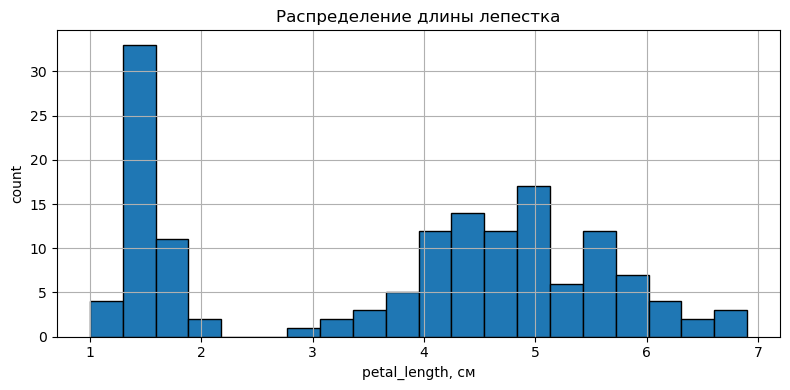

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df['petal_length'].hist(bins=20, ax=ax, edgecolor='black')
ax.set_title('Распределение длины лепестка')
ax.set_xlabel('petal_length, см')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()


*Что мы здесь делали:* Гистограмма показывает явную **бимодальность** — две группы (низкие значения у setosa, высокие у двух других видов). Это первый признак, что данные хорошо разделимы по этому признаку.

## Упражнение 7 — Scatter petal_length vs petal_width

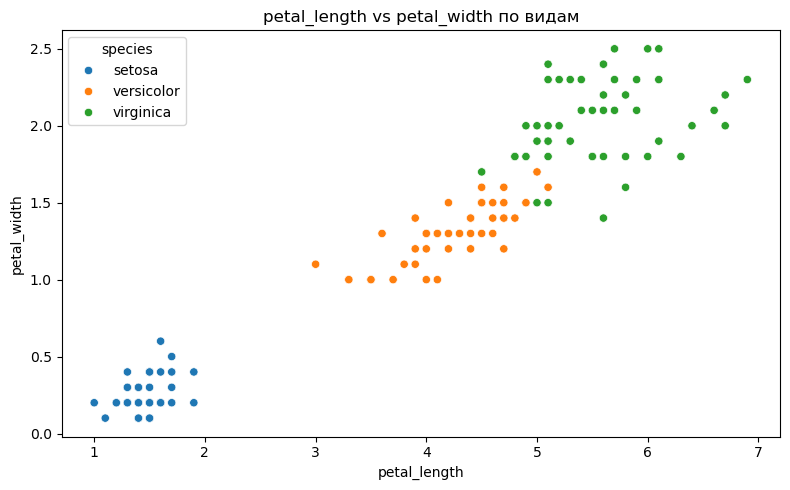

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', ax=ax)
ax.set_title('petal_length vs petal_width по видам')
plt.tight_layout()
plt.show()
# ответ: setosa отделяется идеально (нижний левый угол), versicolor и virginica перекрываются.


*Что мы здесь делали:* Графический способ оценить разделимость классов. Setosa лежит в стороне от двух других — для неё хватит даже простейшего классификатора.

## Упражнение 8 — Pandas → numpy

In [9]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].to_numpy()
y = iris.target  # уже numpy
print(X.shape, y.shape, X.dtype)


(150, 4) (150,) float64


*Что мы здесь делали:* `.to_numpy()` отдаёт numpy-массив. Sklearn принимает оба формата (DataFrame и ndarray), но внутри всё равно работает с numpy.

## Упражнение 9 — Нормализация broadcasting'ом

In [10]:
X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
print('mean:', X_norm.mean(axis=0).round(6))
print('std: ', X_norm.std(axis=0).round(6))


mean: [-0. -0. -0. -0.]
std:  [1. 1. 1. 1.]


*Что мы здесь делали:* Z-score нормализация — приводим каждую колонку к среднему 0 и std 1. Broadcasting автоматически вычитает 4-элементный вектор средних из каждой из 150 строк. Без broadcasting пришлось бы писать цикл.

## Упражнение 10 — Бизнес-вывод

In [11]:
means = df.groupby('species', observed=True)['petal_length'].mean().round(2)
print(means)
diff = means.max() - means.min()
print(f'\nРазница между max и min видом: {diff:.2f} см')
# вывод: лепесток у virginica в среднем в ~3 раза длиннее, чем у setosa — это сильнейший дискриминирующий признак.


species
setosa        1.46
versicolor    4.26
virginica     5.55
Name: petal_length, dtype: float64

Разница между max и min видом: 4.09 см


*Что мы здесь делали:* Простой группировочный анализ — три группы, средние, разница. Это первый шаг к ML-классификации: мы хотим алгоритм, который такую закономерность найдёт автоматически по всем 4 признакам сразу.

---

Готово. Теперь идём в `02_*` — там делаем настоящую модель.